In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import sobel


In [3]:
base = "."

image_root = "./images/train"
image_list = []

for root, dirs, files in os.walk(image_root):
    for file in files:
        if file.lower().endswith(".jpg"):
            image_list.append(os.path.join(root, file))

image_list = sorted(image_list)

print("Total images found:", len(image_list))
print("Example:", image_list[0])

Total images found: 200
Example: ./images/train/100075.jpg


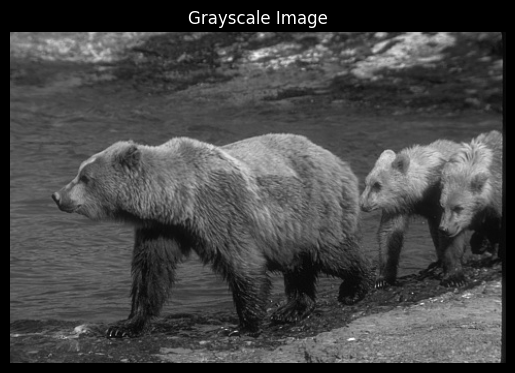

In [4]:
img = Image.open(image_list[0]).convert("L")
img_array = np.array(img)

plt.imshow(img_array, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

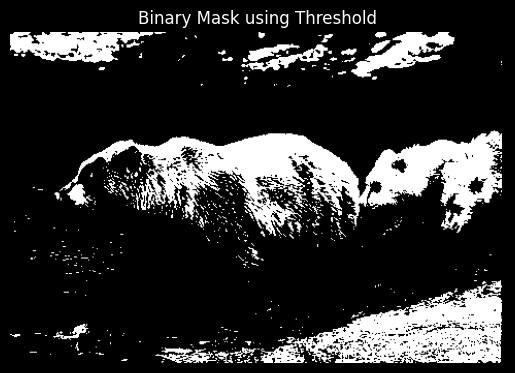

In [5]:
T = 120

mask = (img_array > T).astype(np.uint8)

plt.imshow(mask, cmap="gray")
plt.title("Binary Mask using Threshold")
plt.axis("off")
plt.show()

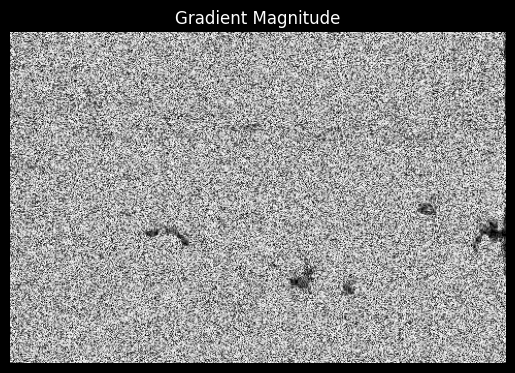

In [6]:
Gx = sobel(img_array, axis=1)
Gy = sobel(img_array, axis=0)

gradient_magnitude = np.sqrt(Gx**2 + Gy**2)

plt.imshow(gradient_magnitude, cmap="gray")
plt.title("Gradient Magnitude")
plt.axis("off")
plt.show()

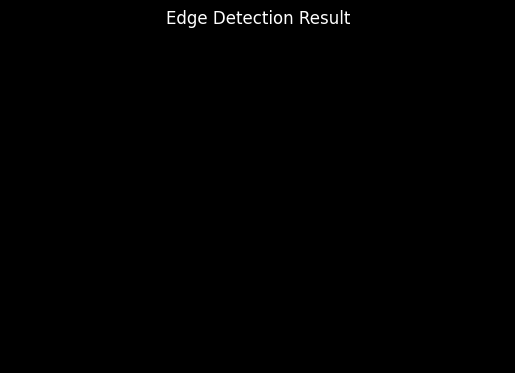

In [7]:
Te = 80

edges = (gradient_magnitude > Te).astype(np.uint8)

plt.imshow(edges, cmap="gray")
plt.title("Edge Detection Result")
plt.axis("off")
plt.show()

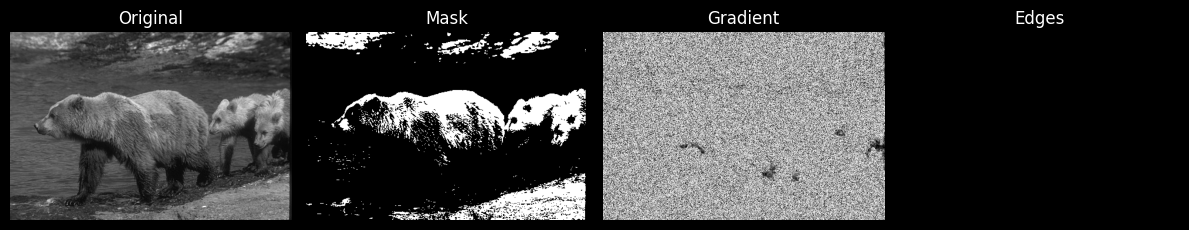

In [8]:
plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(img_array, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(gradient_magnitude, cmap="gray")
plt.title("Gradient")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(edges, cmap="gray")
plt.title("Edges")
plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
mask_folder = "./generated_masks"
os.makedirs(mask_folder, exist_ok=True)

T = 120
print("Using threshold:", T)

Using threshold: 120


In [10]:
for img_path in image_list:
    img = Image.open(img_path).convert("L")
    img_array = np.array(img)

    mask = (img_array > T).astype(np.uint8) * 255

    img_name = os.path.basename(img_path)
    name_without_ext = os.path.splitext(img_name)[0]
    save_path = os.path.join(mask_folder, name_without_ext + "_mask.png")

    Image.fromarray(mask).save(save_path)

print("All masks generated successfully.")

All masks generated successfully.


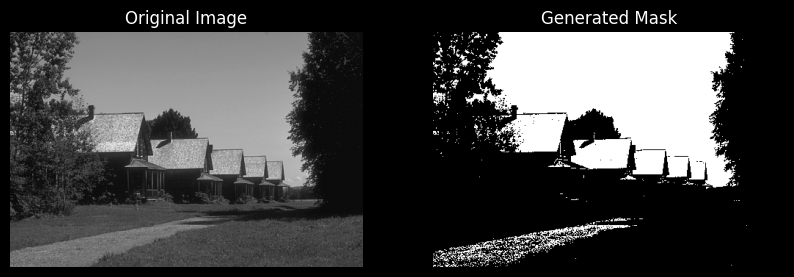

In [11]:
sample_img_path = image_list[100]

img = Image.open(sample_img_path).convert("L")
img_array = np.array(img)

mask_path = os.path.join(
    mask_folder,
    os.path.splitext(os.path.basename(sample_img_path))[0] + "_mask.png"
)
mask = np.array(Image.open(mask_path))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Generated Mask")
plt.axis("off")

plt.show()